In [1]:
# The goal is to make some code that will extract the frames / trajectories from each "state" 
# And basically out put the PDBs 
# And also jsut give a list of those frames basically.

In [2]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import mdtraj
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [3]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [4]:
# Let's just make a test state list


states = array([[0,1,1,2,-1,-1,0,1],
                [3,1,-1,3,4,2,0,1]],
               )

In [5]:
def get_system_state_indices(states):


    unique_states = array(list(sorted(set(states.flatten()))))

    # What we want: for each state, we want a list of all indices [trj,frame] in each state.

    alltrjs=[]
    allframes=[]
    for st_i in range(len(unique_states)):
        st = unique_states[st_i]
        rows,cols = where(states == st)
        alltrjs.append(rows)
        allframes.append(cols)


    allindices = [alltrjs,allframes]
    
    return allindices

allindices = get_system_state_indices(states)

C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 49.99999999999995, 'PC1')

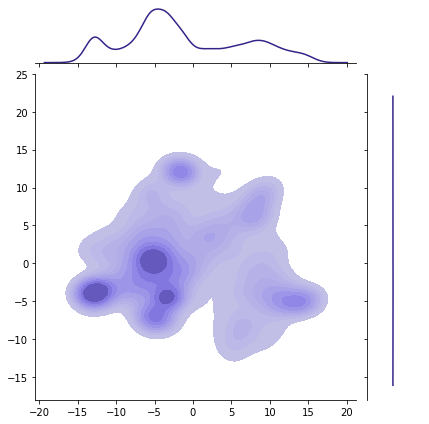

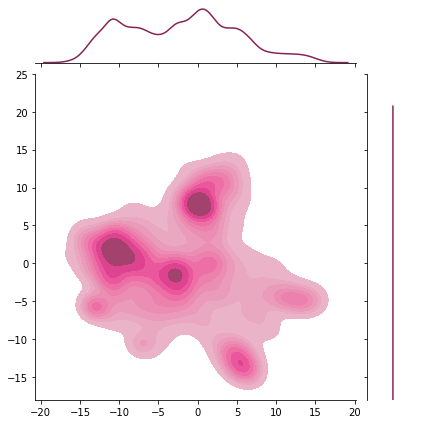

In [6]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists



dists = getPairwiseDists(systems,v1s,v1strings,stride = 1,EQPOINT=EQPOINT)

shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T


#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)
    
    
sns.jointplot(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):], kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)

In [7]:
#.reshape(2,-1)
array(transformed_dists[1])[0].shape

(4001, 2)

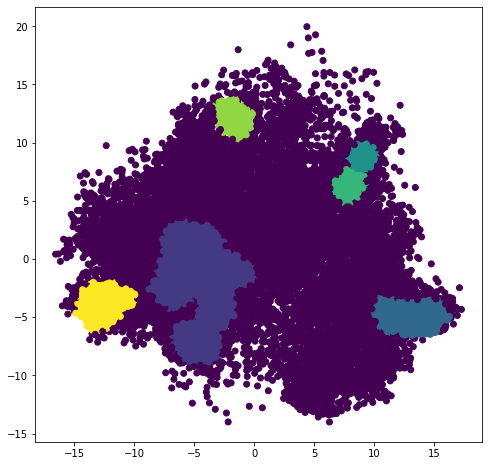

In [8]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=.7,min_samples = 200).fit(array(transformed_dists[1]).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(transformed_dists[1]).reshape(-1,2).T[0],array(transformed_dists[1]).reshape(-1,2).T[1],c = db.labels_)


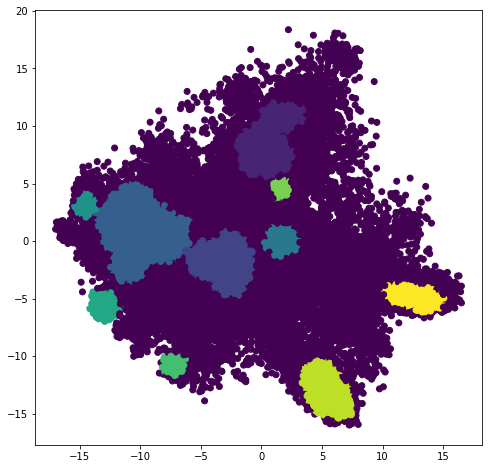

In [9]:
db = DBSCAN(eps=.7,min_samples = 200).fit(array(transformed_dists[2]).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(transformed_dists[2]).reshape(-1,2).T[0],array(transformed_dists[2]).reshape(-1,2).T[1],c = db.labels_)

In [10]:
nStates=8

Text(0.5, 1.0, 'KMeans -- (WT) --  Incredible -- it comes out exactly as you want it to')

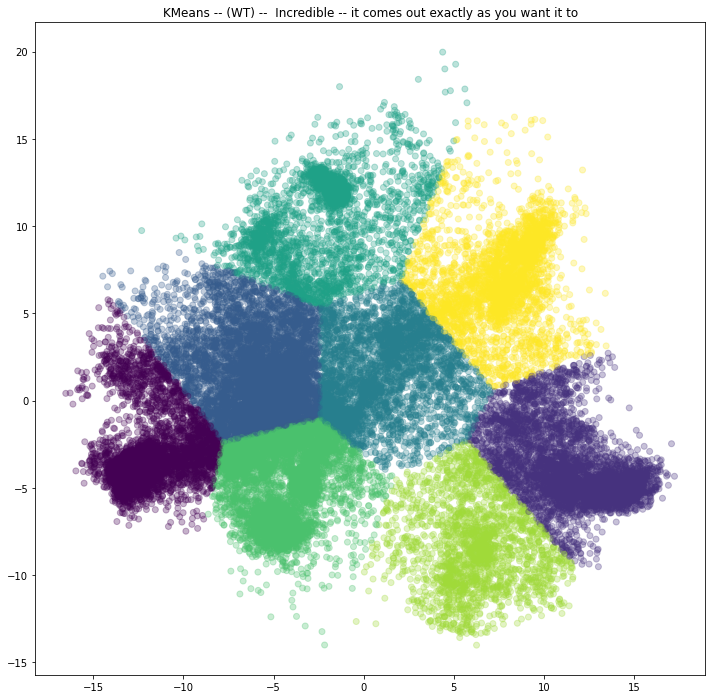

In [11]:
from sklearn.cluster import KMeans

km_w = KMeans(n_clusters = nStates)
km_w.fit(array(transformed_dists[1]).reshape(-1,2))


figure(figsize = (12,12))
scatter(array(transformed_dists[1]).reshape(-1,2)[:,0],array(transformed_dists[1]).reshape(-1,2)[:,1],c = km_w.labels_,alpha = 0.3)
title("KMeans -- (WT) --  Incredible -- it comes out exactly as you want it to")

Text(0.5, 1.0, 'KMeans -- (MUTANT) -- Incredible -- it comes out exactly as you want it to')

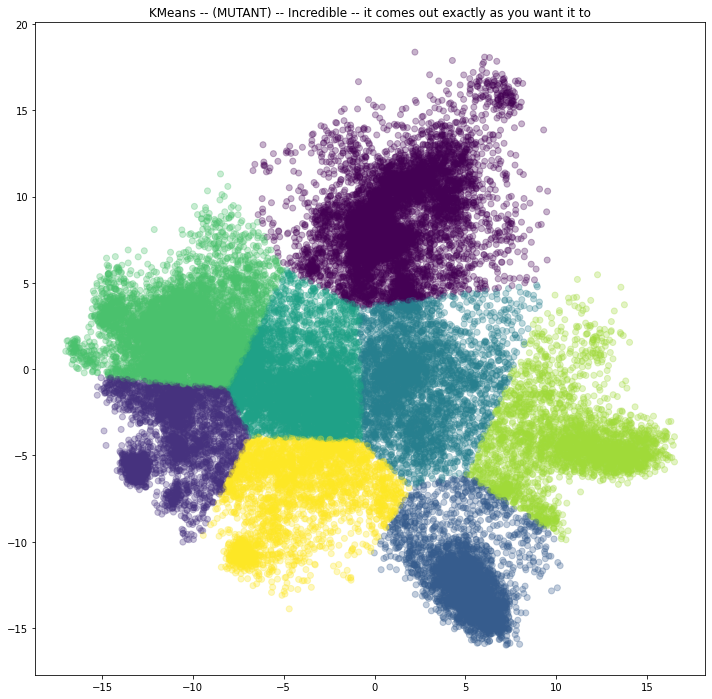

In [12]:
from sklearn.cluster import KMeans

km_m = KMeans(n_clusters = nStates)
km_m.fit(array(transformed_dists[2]).reshape(-1,2))


figure(figsize = (12,12))
scatter(array(transformed_dists[2]).reshape(-1,2)[:,0],array(transformed_dists[2]).reshape(-1,2)[:,1],c = km_m.labels_,alpha = 0.3)
title("KMeans -- (MUTANT) -- Incredible -- it comes out exactly as you want it to")

In [13]:
km_m.cluster_centers_

array([[  1.12885438,   8.64863927],
       [-11.13766332,  -3.91903905],
       [  5.11525635, -12.09337465],
       [  2.43694878,  -0.73164594],
       [ -3.91638797,  -0.84667119],
       [-10.51903776,   2.19653639],
       [ 10.77128367,  -4.22191349],
       [ -4.15698403,  -7.12973802]])

In [14]:
mutant_states = km_m.labels_.reshape(9,4001,)
wildty_states = km_w.labels_.reshape(9,4001,)

mutantindices = get_system_state_indices(mutant_states)
wildtyindices = get_system_state_indices(wildty_states)

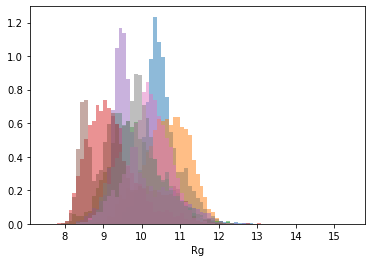

In [15]:
# now, if we want to look at the conformational character of a poarticular states, we just need to reference trhese indices
# Rg, for examp0le
allrgs = load("allrgs.npy")
w_allrgs_thinned = allrgs[1,:]

binrange = arange(7.5,15.5,.1)

for i in range(nStates):
    _=hist(w_allrgs_thinned[wildtyindices[0][i],wildtyindices[1][i]],bins = binrange,alpha = 0.5,density = True)
    
    xlabel("Rg")

In [16]:
# now, if we want to look at the conformational character of a poarticular states, we just need to reference trhese indices
# Rg, for examp0le
def getSSByRes_ts(trjpaths,tprpaths,EQPOINT):
    
    helicityMap={"H":1,"E":0,"C":0}
    betacityMap={"H":0,"E":1,"C":0}
    coilicityMap={"H":0,"E":0,"C":1}
    
    helicity= []
    betacity= []
    coilicity=[]
    
    herr=[]
    berr=[]
    cerr=[]
    
    for i in range(len(trjpaths)):
        subH=[]
        subE=[]
        subC=[]
        for j in range(len(trjpaths[i])):
            t=mdtraj.load(trjpaths[i][j],top=tprpaths[i][j])
            ss1=mdtraj.compute_dssp(t,simplified=True)
            H1=zeros(ss1.shape)
            E1=zeros(ss1.shape)
            C1=zeros(ss1.shape)
            
            for ii in range(len(H1)):
                for jj in range(len(H1[ii])):
                    H1[ii][jj]=helicityMap[ss1[ii][jj]]
                    E1[ii][jj]=betacityMap[ss1[ii][jj]]
                    C1[ii][jj]=coilicityMap[ss1[ii][jj]]
                    
            H1byRes=H1[EQPOINT:]
            subH.append(H1byRes)
            
            E1byRes=E1[EQPOINT:]
            subE.append(E1byRes)
            C1byRes=C1[EQPOINT:]
            subC.append(C1byRes)
            
        helicity.append(subH)
        betacity.append(subE)
        coilicity.append(subC)

    return helicity,betacity,coilicity


helicity_ts,betacity_ts,coilicity_ts=getSSByRes_ts(systemtrjs,systemgros,EQPOINT=EQPOINT)


C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (LEU, GLU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (THR, LEU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ASP, THR)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, ASP)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ARG, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (CYS, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (GLU, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

No handles with labels found to put in legend.


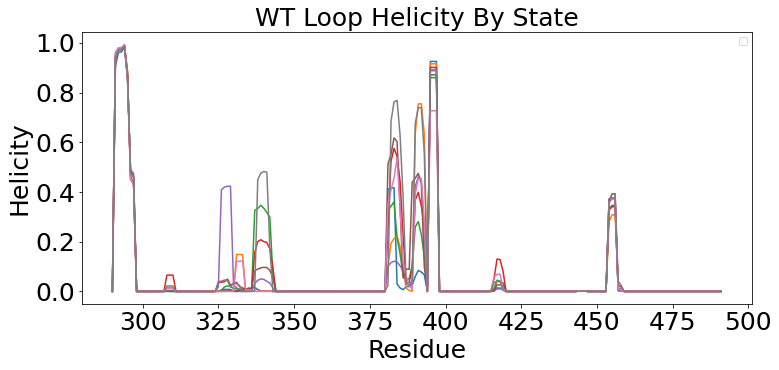

In [17]:
thinned_wt_helicity=array(helicity_ts[1])[:]
#thinned_helicity.shape

#plot(systems[1][0].select_atoms("protein").residues.resids,mean(thinned_wt_helicity[wildtyindices[0][0],wildtyindices[1][0],:],axis = 0),label = "Wa")
figure(figsize = (12,5))
for i in range(nStates):
    plot(systems[1][0].select_atoms("protein").residues.resids,mean(thinned_wt_helicity[wildtyindices[0][i],wildtyindices[1][i],:],axis = 0))

xlabel("Residue",fontsize = 25)
ylabel("Helicity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
#xlim(324,405)
title("WT Loop Helicity By State",fontsize = 25)
legend()

No handles with labels found to put in legend.


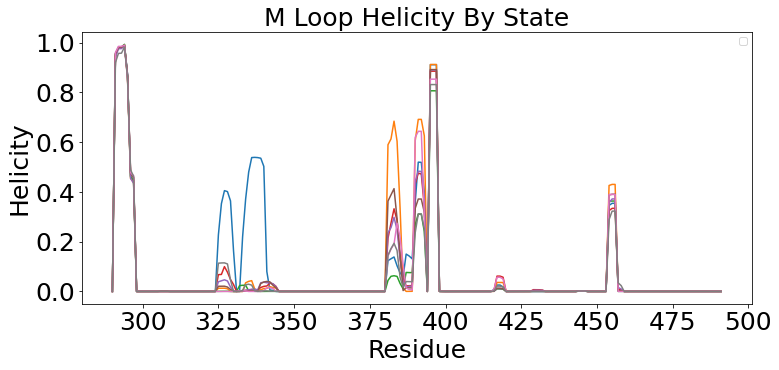

In [18]:
thinned_m_helicity=array(helicity_ts[2])[:]

figure(figsize = (12,5))
for i in range(nStates):
    plot(systems[1][0].select_atoms("protein").residues.resids,mean(thinned_m_helicity[mutantindices[0][i],mutantindices[1][i],:],axis = 0))

xlabel("Residue",fontsize = 25)
ylabel("Helicity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
#xlim(324,405)
title("M Loop Helicity By State",fontsize = 25)
legend()

In [19]:
all_tip_to_com_dists=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        tu = systems[i][j]
        tipres = tu.select_atoms("name CA and resid 332")
        protein = tu.select_atoms("protein and not resid 324:345")
        
        tip_to_com_dists=[]
        for t in range(len(tu.trajectory)):
            tu.trajectory[t]
            tip_to_com=tipres.atoms.positions[0] - protein.center_of_geometry()
            tip_to_com_dist = sqrt(dot(tip_to_com,tip_to_com))
            tip_to_com_dists.append(tip_to_com_dist)
            
        sub.append(tip_to_com_dists)
    all_tip_to_com_dists.append(sub)

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(vals), dtype=np.bool)


No handles with labels found to put in legend.


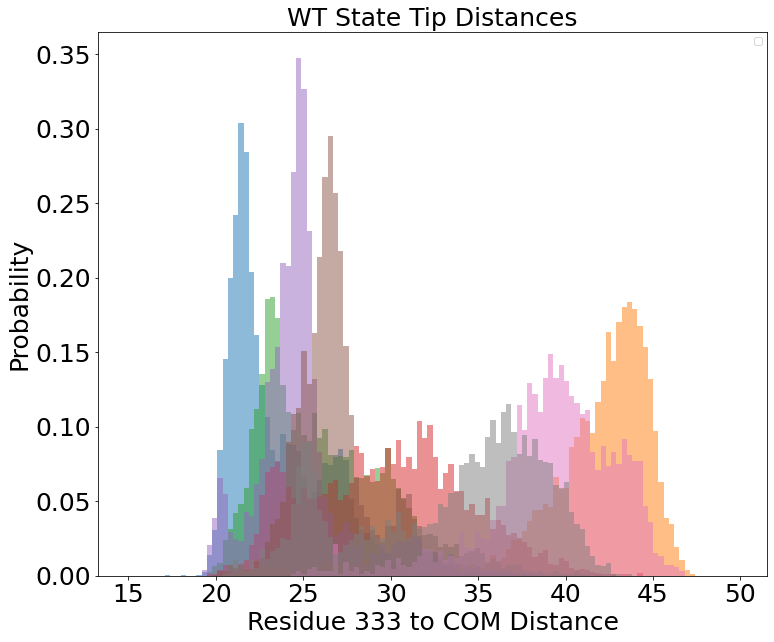

In [20]:
all_tip_to_com_dists_array=array(all_tip_to_com_dists)[1]

binrange = arange(15,50,.3)


figure(figsize = (12,10))
for i in range(nStates):
    _=hist(all_tip_to_com_dists_array[wildtyindices[0][i],wildtyindices[1][i]],bins = binrange,alpha = 0.5,density = True)
xlabel("Residue 333 to COM Distance",fontsize = 25)
ylabel("Probability",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
title("WT State Tip Distances",fontsize = 25)
legend()

No handles with labels found to put in legend.


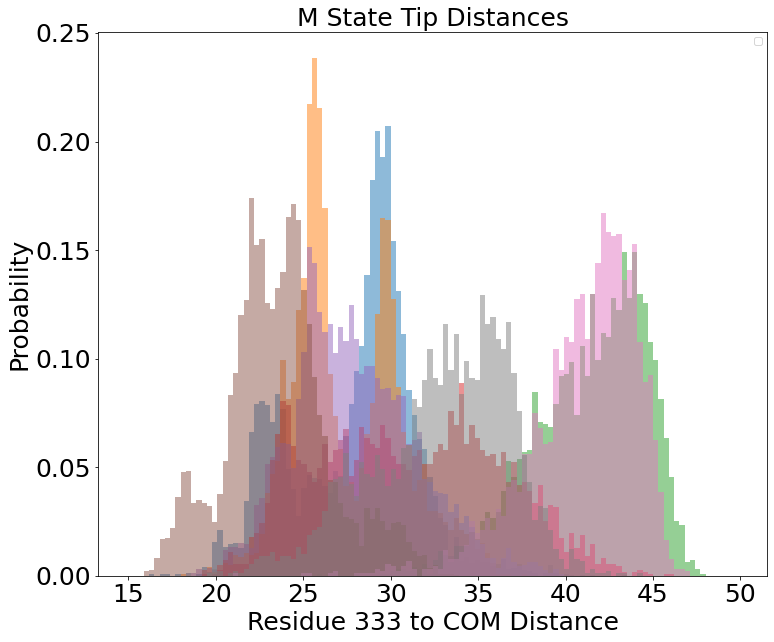

In [21]:
all_tip_to_com_dists_array=array(all_tip_to_com_dists)[2]

binrange = arange(15,50,.3)


figure(figsize = (12,10))
for i in range(nStates):
    _=hist(all_tip_to_com_dists_array[mutantindices[0][i],mutantindices[1][i]],bins = binrange,alpha = 0.5,density = True)

xlabel("Residue 333 to COM Distance",fontsize = 25)
ylabel("Probability",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
title("M State Tip Distances",fontsize = 25)
legend()

In [22]:
# OK but before I get into anything quantitative, I want to just output PDB files from each state and look at a 
# suportposition in VMD to get an "intuitive feel" for the states

wildtyindices
mutantindices



[[array([0, 0, 0, ..., 8, 8, 8], dtype=int64),
  array([0, 0, 0, ..., 8, 8, 8], dtype=int64),
  array([0, 1, 1, ..., 8, 8, 8], dtype=int64),
  array([0, 0, 0, ..., 8, 8, 8], dtype=int64),
  array([0, 0, 0, ..., 8, 8, 8], dtype=int64),
  array([0, 0, 0, ..., 8, 8, 8], dtype=int64),
  array([0, 0, 0, ..., 8, 8, 8], dtype=int64),
  array([0, 0, 0, ..., 8, 8, 8], dtype=int64)],
 [array([   0,    2,    3, ..., 3720, 3731, 3937], dtype=int64),
  array([ 388,  392,  393, ..., 2053, 3715, 3945], dtype=int64),
  array([ 328, 1244, 1251, ..., 3739, 3850, 3852], dtype=int64),
  array([ 289,  290,  322, ..., 3997, 3998, 3999], dtype=int64),
  array([   1,   23,   62, ..., 3981, 3984, 4000], dtype=int64),
  array([ 263,  372,  395, ..., 3952, 3953, 3954], dtype=int64),
  array([ 330,  339,  340, ..., 3847, 3851, 3853], dtype=int64),
  array([ 337,  376,  379, ..., 3970, 3972, 3976], dtype=int64)]]

In [23]:
for i in range(len(wildtyindices[0])):
    nframes = len(wildtyindices[0][i])
    
    for j in range(0,nframes,500):
        tu = systems[1][wildtyindices[0][i][j]]
        tu.trajectory[wildtyindices[1][i][j]]
        
        with MDAnalysis.Writer("wildtype_8state"+str(i)+"_"+str(j)+".pdb") as W:
            W.write(tu.select_atoms("protein"))
    
    

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\coordinates\PDB.py:1026: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\coordinates\PDB.py:1026: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\coordinates\PDB.py:1026: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\coordinates\PDB.py:1026: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'
  warnings.warn("Found no information for attr: '{}'"


In [24]:
for i in range(len(mutantindices[0])):
    nframes = len(mutantindices[0][i])
    
    for j in range(0,nframes,500):
        tu = systems[2][mutantindices[0][i][j]]
        tu.trajectory[mutantindices[1][i][j]]
        
        with MDAnalysis.Writer("mutant_8state"+str(i)+"_"+str(mutantindices[1][i][j])+".pdb") as W:
            W.write(tu.select_atoms("protein"))
    
    

In [25]:
print(1,len(wildtyindices[0][0]))

print(2,len(wildtyindices[0][1]))

print(3,len(wildtyindices[0][2]))

print(4,len(wildtyindices[0][3]))

print(5,len(wildtyindices[0][4]))


1 5255
2 4447
3 7166
4 3683
5 3416


In [26]:
print(1,len(mutantindices[1][0]))

print(2,len(mutantindices[1][1]))

print(3,len(mutantindices[1][2]))

print(4,len(mutantindices[1][3]))

print(5,len(mutantindices[1][4]))

print(6,len(mutantindices[1][5]))

print(7,len(mutantindices[1][6]))

print(8,len(mutantindices[1][7]))



1 7415
2 3481
3 3155
4 3686
5 5235
6 7014
7 3029
8 2994


(array([1335.,    0.,  806.,  269.,  189., 3973.,  196.,  347.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 <BarContainer object of 8 artists>)

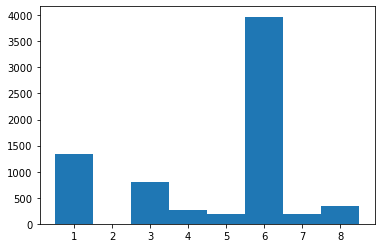

In [32]:
hist(mutantindices[0][0],bins = arange(0.5,9.5,1))

(array([ 284., 1818.,  504.,    7.,  368.,    0.,  116.,   27.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 <BarContainer object of 8 artists>)

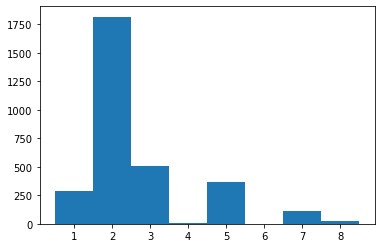

In [33]:
hist(mutantindices[0][1],bins = arange(0.5,9.5,1))

(array([  17.,   73.,  925., 1979.,   26.,    0.,   52.,   82.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 <BarContainer object of 8 artists>)

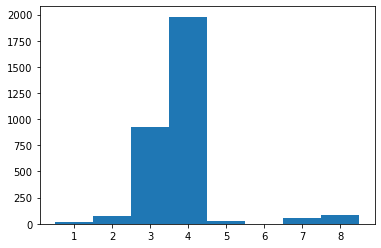

In [34]:
hist(mutantindices[0][2],bins = arange(0.5,9.5,1))

(array([175., 449., 457., 689., 315.,   6., 747., 690.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 <BarContainer object of 8 artists>)

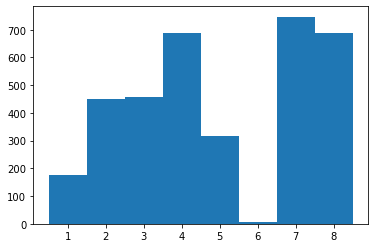

In [35]:
hist(mutantindices[0][3],bins = arange(0.5,9.5,1))

(array([ 259.,   87.,  465.,  163., 1377.,   22.,  710., 1484.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 <BarContainer object of 8 artists>)

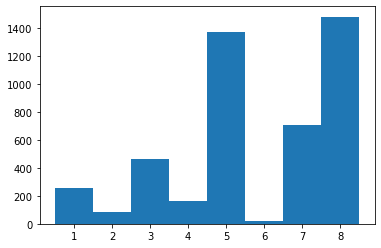

In [36]:
hist(mutantindices[0][4],bins = arange(0.5,9.5,1))

(array([1640.,  960.,  371.,    4., 1576.,    0.,   59.,   66.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 <BarContainer object of 8 artists>)

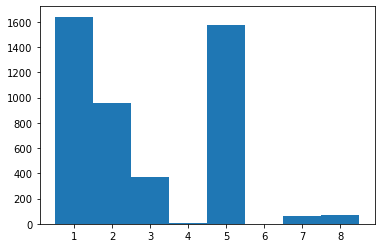

In [37]:
hist(mutantindices[0][5],bins = arange(0.5,9.5,1))

(array([  33.,  437.,   10.,  278.,   25.,    0., 1171., 1071.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 <BarContainer object of 8 artists>)

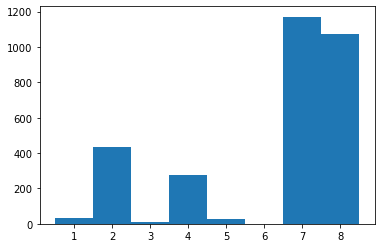

In [38]:
hist(mutantindices[0][6],bins = arange(0.5,9.5,1))

(array([258., 177., 463., 612., 125.,   0., 950., 234.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 <BarContainer object of 8 artists>)

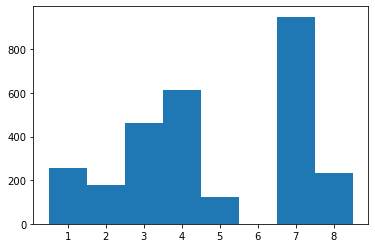

In [39]:
hist(mutantindices[0][7],bins = arange(0.5,9.5,1))

C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


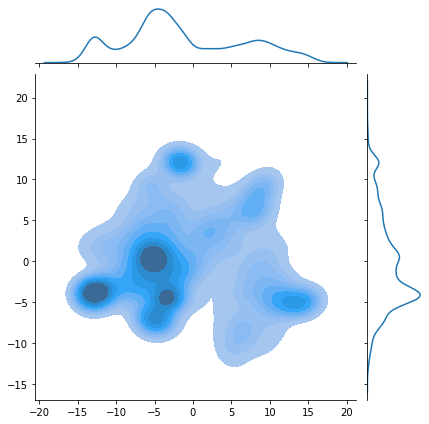

In [56]:
sns.jointplot(*array(transformed_dists[1]).reshape(-1,2).T,shade = True, kind = 'kde')

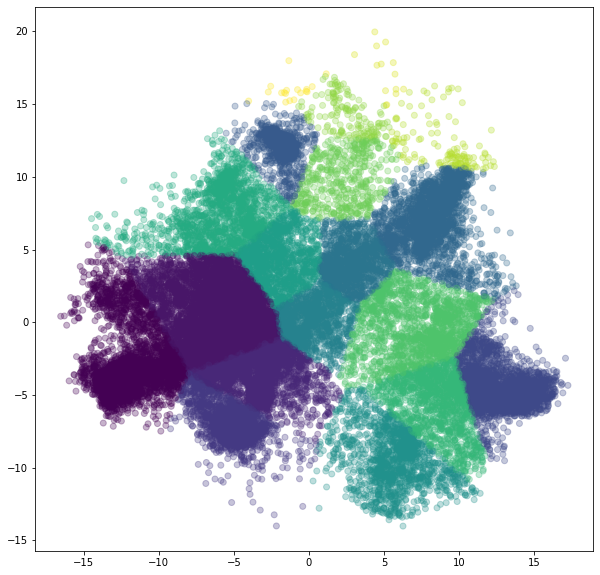

In [73]:
# Let's try meanshift

from sklearn.cluster import MeanShift

ms_wt=MeanShift(bandwidth = 2)
ms_wt.fit(array(transformed_dists[1]).reshape(-1,2))

figure(figsize = (10,10))
scatter(array(transformed_dists[1]).reshape(-1,2).T[0],array(transformed_dists[1]).reshape(-1,2).T[1],c = ms_wt.labels_,alpha = 0.3)
title("bandwidth 2")

Text(0.5, 1.0, 'bandwidth 5')

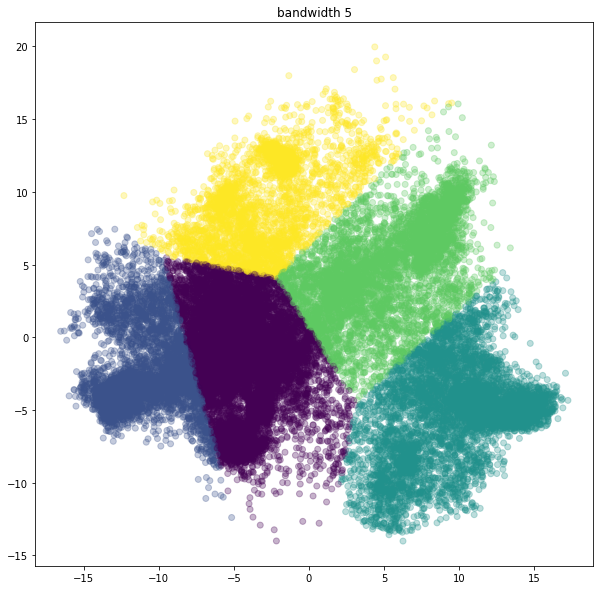

In [76]:
# Let's try meanshift

from sklearn.cluster import MeanShift

ms_wt=MeanShift(bandwidth = 5)
ms_wt.fit(array(transformed_dists[1]).reshape(-1,2))

figure(figsize = (10,10))
scatter(array(transformed_dists[1]).reshape(-1,2).T[0],array(transformed_dists[1]).reshape(-1,2).T[1],c = ms_wt.labels_,alpha = 0.3)
title("bandwidth 5")

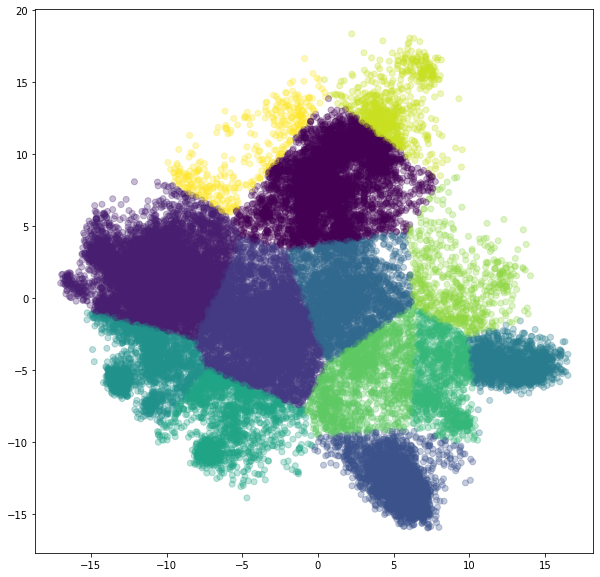

In [72]:
# Let's try meanshift

from sklearn.cluster import MeanShift

ms_m=MeanShift(bandwidth = 2)
ms_m.fit(array(transformed_dists[2]).reshape(-1,2))

figure(figsize = (10,10))
scatter(array(transformed_dists[2]).reshape(-1,2).T[0],array(transformed_dists[2]).reshape(-1,2).T[1],c = ms_m.labels_,alpha = 0.3)
title("bandwidth 2")

Text(0.5, 1.0, 'bandwidth 5')

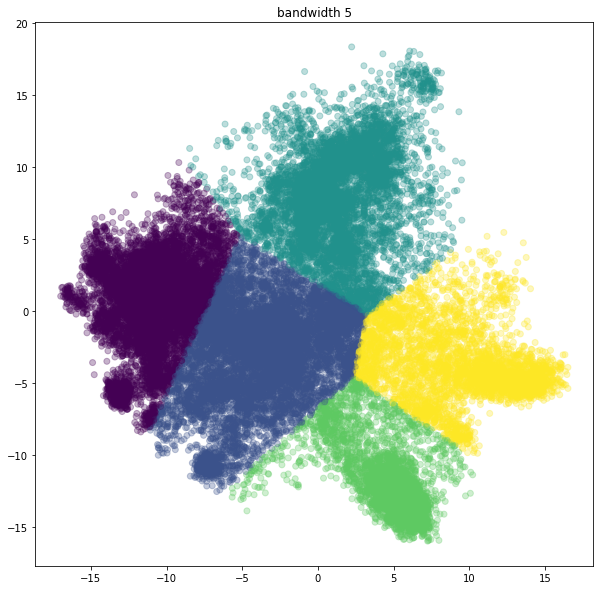

In [75]:
# Let's try meanshift

from sklearn.cluster import MeanShift

ms_m=MeanShift(bandwidth = 5)
ms_m.fit(array(transformed_dists[2]).reshape(-1,2))

figure(figsize = (10,10))
scatter(array(transformed_dists[2]).reshape(-1,2).T[0],array(transformed_dists[2]).reshape(-1,2).T[1],c = ms_m.labels_,alpha = 0.3)
title("bandwidth 5")